In [1]:
from PIL import Image
from pillow_heif import register_heif_opener
import os
import cv2
import numpy as np
import shutil
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

CARGA DE DATA SET
Aqui se realiza la carga del data set, solo hay que colocar la direccion de la carpeta y el mismo las busca y las etiqueta segun el orden de la carpeta
El tamaño del redmencionamiento solo es para dejar cuadrada la imagen, se deja alto para que haya mas informacion cuando se aplique el filtro de quitar negros

In [ ]:
register_heif_opener()
def load_and_label_data(folder):
    images = []
    labels = []
    
    # Listar las subcarpetas (clases)
    class_folders = sorted(os.listdir(folder))
    
    for label, class_folder in enumerate(class_folders):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
            
        print(f"Procesando clase '{class_folder}' (Etiqueta: {label})...")
        
        for i, filename in enumerate(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            
           
            img = None
            try:
                if filename.lower().endswith(".heic"):
                   
                    temp_pil = Image.open(img_path)
                    img = cv2.cvtColor(np.array(temp_pil), cv2.COLOR_RGB2BGR)
                else:
                    # Carga normal para JPG, PNG, etc.
                    img = cv2.imread(img_path)
            except Exception as e:
                print(f"  [!] No se pudo procesar '{filename}': {e}")
                continue
            if img is None:
                continue
            # --- 2. PROCESAMIENTO Y ETIQUETADO ---
            # Este refimencionamiento solo es provicional para ajustar la imagen cuadrada
            img_resized = cv2.resize(img, (720, 720))
            # Mostrar muestra visual 
            if i < 1:
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                axes[0].set_title(f'Original: {filename}')
                axes[1].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
                axes[1].set_title('Redimensionada')
                plt.show()
            # Agregamos a nuestras listas finales (X e y)
            images.append(img_resized)
            labels.append(label)
    print(f"Carga completada: {len(images)} imágenes procesadas.")
    return np.array(images), np.array(labels)



La segmentacion tiene unos valores ya ajustados al requerimiento de brillo y fondo

In [ ]:
def segmentar_solo_color(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


    lower_bg = np.array([0,  0,  10])   #Valores ajustables
    upper_bg = np.array([180, 40, 190])   #Valores ajustables

    mask_bg  = cv2.inRange(hsv, lower_bg, upper_bg)
    mask_obj = cv2.bitwise_not(mask_bg)

    # Cerrar huecos internos y eliminar ruido pequeño
    kernel_close = np.ones((9, 9), np.uint8)
    kernel_open  = np.ones((5, 5), np.uint8)
    mask_obj = cv2.morphologyEx(mask_obj, cv2.MORPH_CLOSE, kernel_close)
    mask_obj = cv2.morphologyEx(mask_obj, cv2.MORPH_OPEN,  kernel_open)

    # Quedarse solo con el contorno más grande (elimina manchas residuales)
    contours, _ = cv2.findContours(mask_obj, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask_clean = np.zeros_like(mask_obj)
        cv2.drawContours(mask_clean, [largest], -1, 255, thickness=cv2.FILLED)
        mask_obj = mask_clean

    result = cv2.bitwise_and(img, img, mask=mask_obj)
    return result

Funcion de filtros, tiene varios filtros pero solo se usa el de aumento de brillo

In [ ]:

def filtros(X, 
            blur=False, 
            gaussian=False, 
            median=False,
            sharpen=False,
            edges=False,
            brightness=0,
            contrast=1.0):
    
    X_out = []

    for img in X:
        img_proc = img.copy()

        # Asegurar tipo uint8
        if img_proc.dtype != np.uint8:
            img_proc = (img_proc * 255).astype(np.uint8)

        # Blur promedio
        if blur:
            img_proc = cv2.blur(img_proc, (3, 3))

        # Gaussian Blur
        if gaussian:
            img_proc = cv2.GaussianBlur(img_proc, (3, 3), 0)

        # Median Blur
        if median:
            img_proc = cv2.medianBlur(img_proc, 3)

        # Sharpen (enfoque)
        if sharpen:
            kernel = np.array([[0, -1, 0],
                               [-1, 5,-1],
                               [0, -1, 0]])
            img_proc = cv2.filter2D(img_proc, -1, kernel)

        # Detección de bordes
        if edges:
            img_proc = cv2.Canny(img_proc, 100, 200)

        # Brillo y contraste
        img_proc = cv2.convertScaleAbs(img_proc, alpha=contrast, beta=brightness)

        X_out.append(img_proc)

    return np.array(X_out)

Ejecucion de etiquetado de datos, solo se guardan en variables internas

Procesando clase 'Botellas_Plasticas' (Etiqueta: 0)...


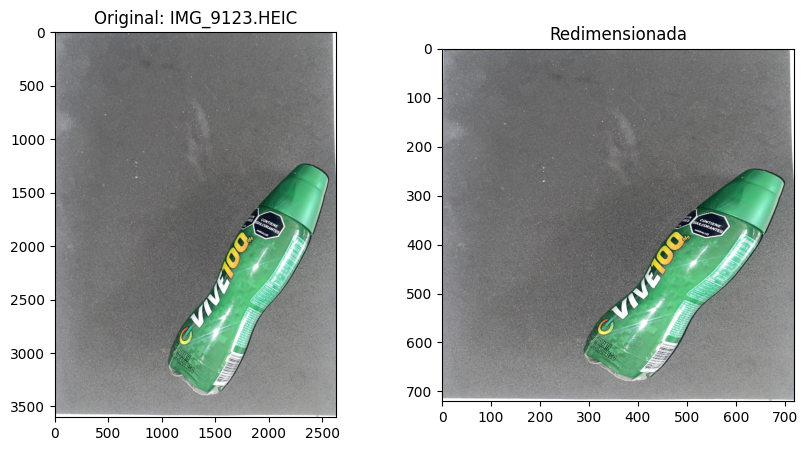

Procesando clase 'Latas_Metalicas' (Etiqueta: 1)...


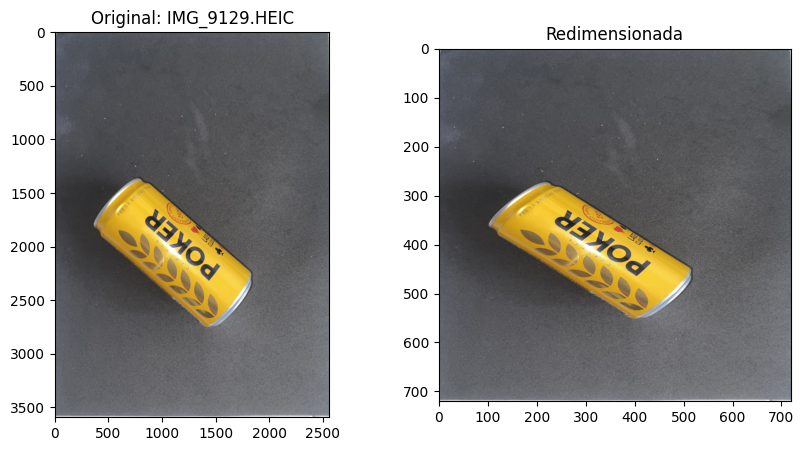

Procesando clase 'Mecato' (Etiqueta: 2)...


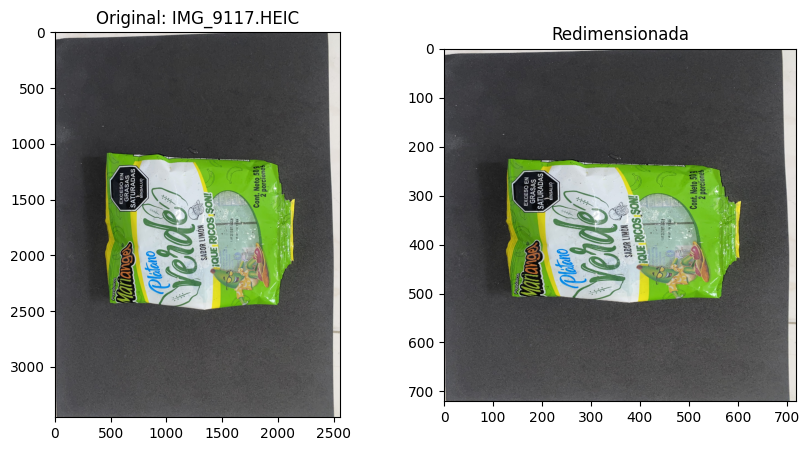

Procesando clase 'Papel_Carton' (Etiqueta: 3)...
Carga completada: 16 imágenes procesadas.
Forma de X (Imágenes): (16, 720, 720, 3)
Forma de y (Etiquetas): (16,)


In [ ]:
ruta_path = './Data_Basuras'
data_folder = ruta_path
# Cargar y etiquetar las imágenes y guardar las imágenes redimensionadas
X, Y = load_and_label_data(data_folder)
print(f"Forma de X (Imágenes): {X.shape}") 
print(f"Forma de y (Etiquetas): {Y.shape}") 



Aplicacion de filtros, para el caso funciono bien con un aumento de brillo leve

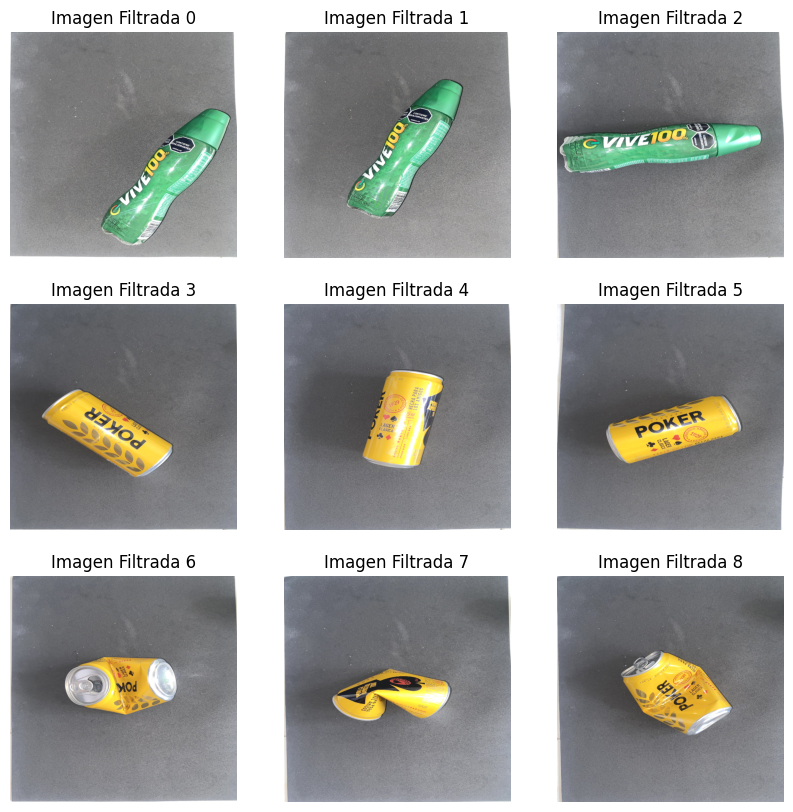

In [53]:
X_filtrado = filtros(
    X,
    gaussian=False,
    sharpen=False,
    brightness=15,
    contrast=1
)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Convertir BGR a RGB para mostrar con Matplotlib
    plt.imshow(cv2.cvtColor(X_filtrado[i], cv2.COLOR_BGR2RGB))
    plt.title(f"Imagen Filtrada {i}")
    plt.axis("off")
plt.show()

Ejecucion de la segmentacion del color
Aqui si se coloca el tamaño final de los pixeles(Importante)

Iniciando segmentación híbrida en 16 imágenes...
¡Proceso de segmentación finalizado!


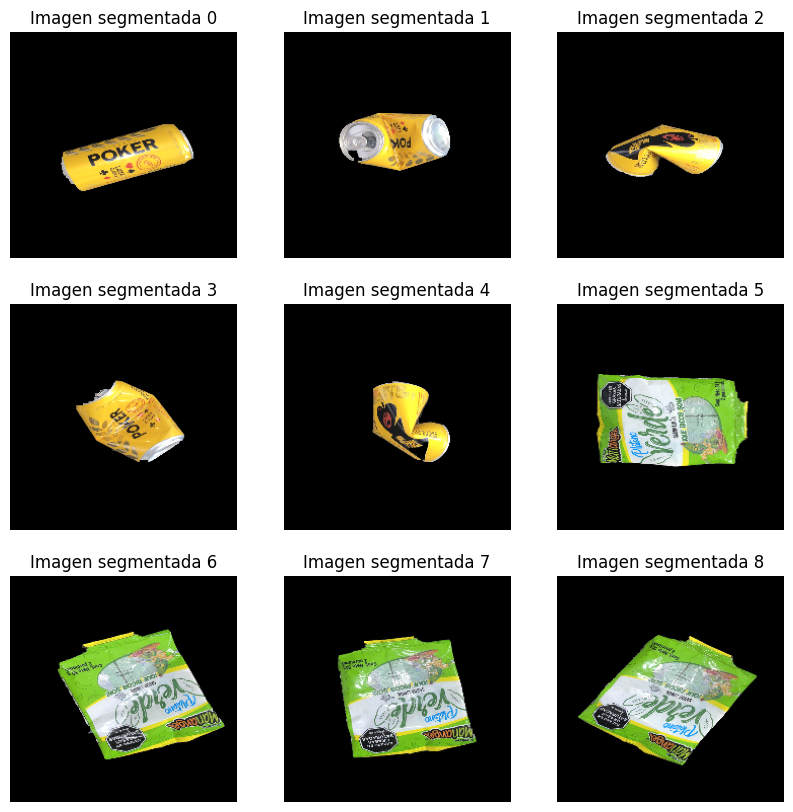

In [59]:
X_segmentada = []
print(f"Iniciando segmentación híbrida en {len(X)} imágenes...")

for i in range(len(X)):
    img_proc = segmentar_solo_color(X_filtrado[i])
    img_resized = cv2.resize(img_proc, (224, 224))
    X_segmentada.append(img_resized)
X_SinFondo = np.array(X_segmentada)

print("¡Proceso de segmentación finalizado!")
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Convertir BGR a RGB para mostrar con Matplotlib
    plt.imshow(cv2.cvtColor(X_SinFondo[i+5], cv2.COLOR_BGR2RGB))
    plt.title(f"Imagen segmentada {i}")
    plt.axis("off")
plt.show()

Esta funcion lo que permite es aumentar el objeto al tamaño total del cuadrado de los pixeles, sirve para que la red aprenda mas del objeto y se confunda con el negro
Importante colocar el mismo tamaño de pixeles que cuando se segmento el negro

In [60]:
def centrar_y_redimensionar(img, size=224):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    recorte = img[y:y+h, x:x+w]

    # Crear fondo negro cuadrado
    max_dim = max(w, h)
    fondo = np.zeros((max_dim, max_dim, 3), dtype=np.uint8)

    # centrar
    x_offset = (max_dim - w) // 2
    y_offset = (max_dim - h) // 2

    fondo[y_offset:y_offset+h, x_offset:x_offset+w] = recorte

    # resize final
    final = cv2.resize(fondo, (size, size))

    return final

Data ser listo para entrenar, aun conserva las 3 capas RGB

Iniciando segmentación híbrida en 16 imágenes...
¡Proceso de segmentación finalizado!


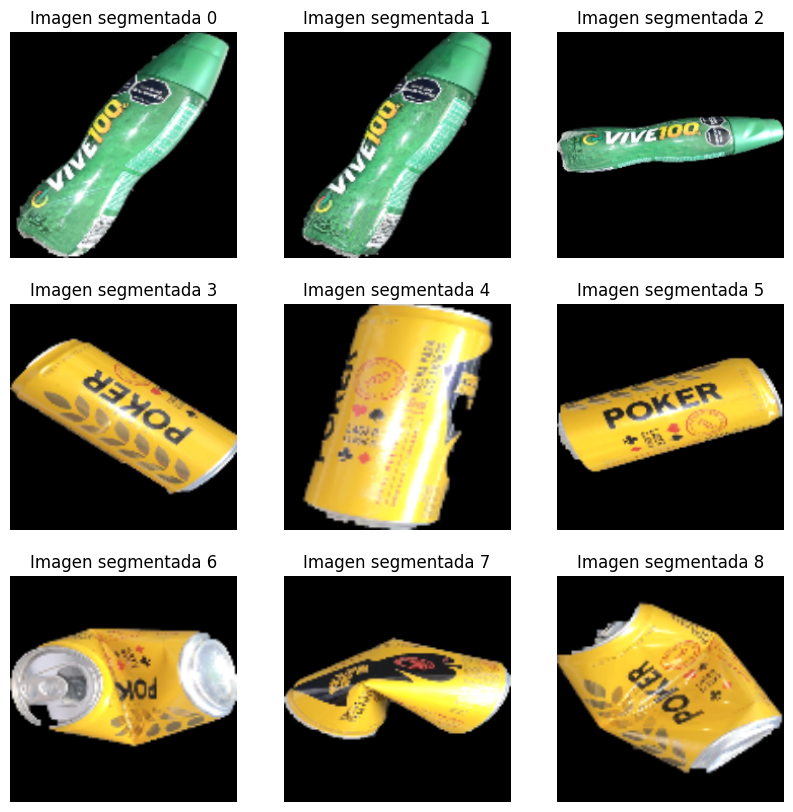

In [62]:
X_final = []
print(f"Iniciando segmentación híbrida en {len(X)} imágenes...")

for i in range(len(X)):
    img_proc = centrar_y_redimensionar(X_SinFondo[i])
    img_resized = cv2.resize(img_proc, (224, 224))
    X_final.append(img_resized)
X_Final = np.array(X_final)

print("¡Proceso de segmentación finalizado!")
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Convertir BGR a RGB para mostrar con Matplotlib
    plt.imshow(cv2.cvtColor(X_Final[i], cv2.COLOR_BGR2RGB))
    plt.title(f"Imagen segmentada {i}")
    plt.axis("off")
plt.show()